# Results Analysis: Precision Tiers and Material Stock

This notebook reads the saved outputs from `05_typology_assignment_revised.ipynb`.

It does **not** rerun typology assignment or material-intensity calculation. It only creates:

1. Primary typology confidence reporting using the A/B/C/D `confidence_tier` scale and thesis-facing `confidence_label`.
2. Statistical summaries of assignment levels, confidence tiers, quality flags, GFA, and material stock.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.geometry import box
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data/processed"
MAP_DIR = PROJECT_ROOT / "results/maps"

RESIDENTIAL_RESULTS_PATH = PROCESSED_DIR / "hamburg_residential_buildings_with_heeren_material_estimates.gpkg"
ALL_BUILDINGS_RESULTS_PATH = PROCESSED_DIR / "hamburg_buildings_with_heeren_material_estimates.gpkg"
ASSIGNMENT_SUMMARY_PATH = PROCESSED_DIR / "hamburg_heeren_assignment_level_summary.csv"
CONFIDENCE_SUMMARY_PATH = PROCESSED_DIR / "hamburg_heeren_confidence_tier_summary.csv"
QUALITY_FLAGS_SUMMARY_PATH = PROCESSED_DIR / "hamburg_heeren_quality_flags_summary.csv"
COMPARISON_LAYER_COVERAGE_PATH = PROCESSED_DIR / "hamburg_comparison_layer_coverage_summary.csv"
UNASSIGNED_REASON_SUMMARY_PATH = PROCESSED_DIR / "hamburg_unassigned_reason_summary.csv"
IOER_QA_PATH = PROCESSED_DIR / "hamburg_ioer_reference_qa.csv"
IOER_MATERIAL_GROUP_SUMMARY_PATH = PROCESSED_DIR / "hamburg_ioer_benchmark_material_group_summary.csv"
MATERIAL_INTENSITY_BY_AGE_PATH = PROCESSED_DIR / "hamburg_material_intensity_by_construction_period.csv"

CONFIDENCE_TIER_MAP_PATH = MAP_DIR / "hamburg_residential_confidence_tier_map.png"
CONFIDENCE_TIER_HEATMAP_PATH = MAP_DIR / "hamburg_residential_confidence_tier_heatmap.png"
LOW_CONFIDENCE_SHARE_HEATMAP_PATH = MAP_DIR / "hamburg_residential_low_confidence_share_heatmap.png"
TOTAL_STOCK_BY_TIER_MAP_PATH = MAP_DIR / "hamburg_residential_total_stock_by_confidence_tier_map.png"

MAP_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 160)

CONFIDENCE_TIER_LABELS = {
    "A_direct": "A - Direct match",
    "B_representative": "B - Representative match",
    "C_fallback": "C - Fallback estimate",
    "D_unassigned": "D - Unassigned",
}
PRIMARY_CONFIDENCE_TIER_ORDER = ["A_direct", "B_representative", "C_fallback", "D_unassigned"]
PRIMARY_CONFIDENCE_SCORE_MAP = {
    "A_direct": 4,
    "B_representative": 3,
    "C_fallback": 2,
    "D_unassigned": 0,
}


## Load Saved Results

In [2]:
required_paths = [
    RESIDENTIAL_RESULTS_PATH,
    ASSIGNMENT_SUMMARY_PATH,
    CONFIDENCE_SUMMARY_PATH,
    QUALITY_FLAGS_SUMMARY_PATH,
    COMPARISON_LAYER_COVERAGE_PATH,
    UNASSIGNED_REASON_SUMMARY_PATH,
    IOER_QA_PATH,
    IOER_MATERIAL_GROUP_SUMMARY_PATH,
]
missing_paths = [path for path in required_paths if not path.exists() or path.stat().st_size == 0]
if missing_paths:
    raise FileNotFoundError(
        "Run 05_typology_assignment_revised.ipynb first. Missing outputs: "
        + ", ".join(str(path) for path in missing_paths)
    )

gdf_residential = gpd.read_file(RESIDENTIAL_RESULTS_PATH)
assignment_summary = pd.read_csv(ASSIGNMENT_SUMMARY_PATH)
confidence_summary = pd.read_csv(CONFIDENCE_SUMMARY_PATH)
quality_flags_summary = pd.read_csv(QUALITY_FLAGS_SUMMARY_PATH)
comparison_layer_coverage = pd.read_csv(COMPARISON_LAYER_COVERAGE_PATH)
unassigned_reason_summary = pd.read_csv(UNASSIGNED_REASON_SUMMARY_PATH)
ioer_reference_qa = pd.read_csv(IOER_QA_PATH)
ioer_material_group_summary = pd.read_csv(IOER_MATERIAL_GROUP_SUMMARY_PATH)

numeric_columns = [
    "estimated_gfa_m2",
    "total_material_stock_kg",
    "total_material_stock_t",
    "construction_year_clean",
    "above_ground_storeys_clean",
    "underground_storeys_clean",
    "underground_storeys_for_gfa",
    "total_storeys_for_gfa",
    "grundflaeche_clean_m2",
    "n_heeren_rows_averaged",
    "n_reference_typologies_averaged",
    "ortlepp_variant_material_total_t",
    "ortlepp_variant_total_intensity_kg_m2",
    "difference_primary_vs_ortlepp_t",
    "difference_primary_vs_ortlepp_percent",
    "ioer_total_material_stock_t",
]
for col in numeric_columns:
    if col in gdf_residential.columns:
        gdf_residential[col] = pd.to_numeric(gdf_residential[col], errors="coerce")

stock_t_columns = [
    col for col in gdf_residential.columns
    if col.endswith("_stock_t")
    and col != "total_material_stock_t"
    and not col.startswith("ioer_material_group_")
    and not col.startswith("ortlepp_variant_")
]
ioer_material_group_stock_columns = [col for col in gdf_residential.columns if col.startswith("ioer_material_group_") and col.endswith("_stock_t")]
for col in stock_t_columns:
    gdf_residential[col] = pd.to_numeric(gdf_residential[col], errors="coerce")

if "confidence_label" not in gdf_residential.columns:
    gdf_residential["confidence_label"] = gdf_residential["confidence_tier"].map(CONFIDENCE_TIER_LABELS).fillna(gdf_residential["confidence_tier"])
if "benchmark_role" not in gdf_residential.columns:
    gdf_residential["benchmark_role"] = pd.NA
    has_ioer_benchmark = gdf_residential.get("ioer_total_material_stock_t", pd.Series(pd.NA, index=gdf_residential.index)).notna()
    gdf_residential.loc[has_ioer_benchmark, "benchmark_role"] = "ioer_benchmark"

print("Residential buildings loaded:", len(gdf_residential))
print("CRS:", gdf_residential.crs)
print("Primary confidence tiers:", sorted(gdf_residential["confidence_tier"].dropna().unique()))

form_column = "bauweise_group" if "bauweise_group" in gdf_residential.columns else "building_form_class"
preview_columns = [
    "gml_id",
    form_column,
    "assignment_role",
    "assignment_level",
    "confidence_tier",
    "confidence_label",
    "assigned_typology_ids",
    "assignment_reference_kind",
    "estimated_gfa_m2",
    "total_material_stock_t",
    "ortlepp_variant_heeren_id",
    "ortlepp_variant_material_total_t",
    "difference_primary_vs_ortlepp_t",
    "ioer_variant_type",
    "benchmark_role",
    "ioer_total_material_stock_t",
    "quality_flags",
]
preview_columns = [column for column in preview_columns if column in gdf_residential.columns]
gdf_residential[preview_columns].head()


Residential buildings loaded: 227334
CRS: EPSG:25832
Primary confidence tiers: ['A_direct', 'B_representative', 'C_fallback', 'D_unassigned']


,gml_id,bauweise_group,assignment_role,assignment_level,confidence_tier,confidence_label,assigned_typology_ids,assignment_reference_kind,estimated_gfa_m2,total_material_stock_t,ortlepp_variant_heeren_id,ortlepp_variant_material_total_t,difference_primary_vs_ortlepp_t,ioer_variant_type,benchmark_role,ioer_total_material_stock_t,quality_flags
0,DEHHALKAz0000QCI,detached_sfh,primary,3_gruhler_fallback_average,C_fallback,C - Fallback estimate,114+115+116+117+118,unweighted_average,120.0,152.736366,,NaN,NaN,IÖR_EFH_Hamburg,ioer_benchmark,161.372208,year_missing;gruhler_fallback_used
1,DEHHALKAz0000Qj1,detached_sfh,primary,3_gruhler_fallback_average,C_fallback,C - Fallback estimate,114+115+116+117+118,unweighted_average,146.0,185.829246,,NaN,NaN,IÖR_EFH_Hamburg,ioer_benchmark,196.336187,year_missing;gruhler_fallback_used
2,DEHHALKAz0000Tb0,detached_sfh,primary,3_gruhler_fallback_average,C_fallback,C - Fallback estimate,114+115+116+117+118,unweighted_average,246.0,313.109551,,NaN,NaN,IÖR_EFH_Hamburg,ioer_benchmark,330.813027,year_missing;gruhler_fallback_used
3,DEHHALKAz0000QP3,detached_sfh,primary,1_gruhler_specific_typology,B_representative,B - Representative match,115,single_typology,342.0,516.483333,,NaN,NaN,IÖR_EFH_Hamburg,ioer_benchmark,459.910793,attic_proxy_used;two_storey_sfh_extension
4,DEHHALKAz0000Qwm,row_terraced_grouped_sfh,primary,2_gruhler_candidate_average,B_representative,B - Representative match,119+120,unweighted_average,204.0,243.843692,134,443.904,-200.060308,IÖR_MFH_Hamburg,ioer_benchmark,260.190775,candidate_average_used


## Analysis Dataset Scope Check

This checks that the downstream results notebook is using the full selected residential building stock from notebook 05. Buildings with missing storeys remain in the dataset, but they cannot receive calculated material stock tonnes unless `estimated_gfa_m2` is available.


In [3]:
missing_prerequisites = [name for name in ['gdf_residential', 'comparison_layer_coverage', 'unassigned_reason_summary', 'ioer_reference_qa'] if name not in globals()]
if missing_prerequisites:
    raise RuntimeError(
        'Run the setup and Load Saved Results cells above first.'
        + " Missing: " + ", ".join(missing_prerequisites)
    )

assigned_mask = gdf_residential["assignment_level"].fillna("").astype("string").str.match(r"^[1-5]_")
gfa_valid_mask = gdf_residential["estimated_gfa_m2"].notna() & gdf_residential["estimated_gfa_m2"].gt(0)
stock_valid_mask = gdf_residential["total_material_stock_t"].notna() & gdf_residential["total_material_stock_t"].gt(0)
ortlepp_sensitivity_mask = gdf_residential.get("ortlepp_variant_material_total_t", pd.Series(pd.NA, index=gdf_residential.index)).notna()
ioer_benchmark_mask = gdf_residential.get("ioer_total_material_stock_t", pd.Series(pd.NA, index=gdf_residential.index)).notna()

quality_flags_text = gdf_residential.get("quality_flags", pd.Series("", index=gdf_residential.index)).fillna("").astype("string")
storeys_missing_mask = quality_flags_text.str.contains("storeys_missing_or_invalid", regex=False)
footprint_missing_mask = quality_flags_text.str.contains("footprint_missing_or_invalid", regex=False)
gfa_missing_flag_mask = quality_flags_text.str.contains("gfa_missing_or_invalid", regex=False)

analysis_scope_check = pd.DataFrame(
    {
        "metric": [
            "residential_buildings_loaded_from_05_output",
            "buildings_assigned_material_intensity",
            "buildings_with_valid_estimated_gfa",
            "buildings_missing_or_invalid_estimated_gfa",
            "buildings_with_storeys_missing_or_invalid_flag",
            "buildings_with_footprint_missing_or_invalid_flag",
            "buildings_with_gfa_missing_or_invalid_flag",
            "buildings_with_calculable_material_stock",
            "buildings_with_ortlepp_sensitivity_result",
            "buildings_with_ioer_benchmark_result",
        ],
        "building_count": [
            len(gdf_residential),
            int(assigned_mask.sum()),
            int(gfa_valid_mask.sum()),
            int((~gfa_valid_mask).sum()),
            int(storeys_missing_mask.sum()),
            int(footprint_missing_mask.sum()),
            int(gfa_missing_flag_mask.sum()),
            int(stock_valid_mask.sum()),
            int(ortlepp_sensitivity_mask.sum()),
            int(ioer_benchmark_mask.sum()),
        ],
    }
)
analysis_scope_check["share_of_loaded_residential_buildings_pct"] = (
    analysis_scope_check["building_count"] / len(gdf_residential) * 100
).round(3)

display(analysis_scope_check)


display(comparison_layer_coverage)
display(unassigned_reason_summary.head(20))
display(ioer_reference_qa)


,metric,building_count,share_of_loaded_residential_buildings_pct
0,residential_buildings_loaded_from_05_output,227334,100.000
1,buildings_assigned_material_intensity,157065,69.090
2,buildings_with_valid_estimated_gfa,227109,99.901
3,buildings_missing_or_invalid_estimated_gfa,225,0.099
4,buildings_with_storeys_missing_or_invalid_flag,224,0.099
5,buildings_with_footprint_missing_or_invalid_flag,1,0.000
6,buildings_with_gfa_missing_or_invalid_flag,225,0.099
7,buildings_with_calculable_material_stock,157025,69.072
8,buildings_with_ortlepp_sensitivity_result,82391,36.242
9,buildings_with_ioer_benchmark_result,206167,90.689


,comparison_layer,building_count,covered_estimated_gfa_m2,total_material_stock_t,share_of_residential_buildings_pct,share_of_residential_gfa_pct
0,primary,157065,9.612136e+07,1.713075e+08,69.09,73.89
1,ortlepp_sensitivity,82391,7.746453e+07,1.736183e+08,36.24,59.55
2,ioer_benchmark,206167,1.156080e+08,1.495376e+08,90.69,88.87
3,unassigned_residential,70269,3.396397e+07,NaN,30.91,26.11


,unassigned_reason,building_count,estimated_gfa_m2
0,no_csv_defined_typology_or_fallback_for_availa...,48643,19199557.83
1,bauweise_not_in_csv_assignment_groups,21010,14477332.00
2,sfh_no_usable_year_and_no_matching_csv_fallbac...,616,287084.00


,ioer_variant_type,material_typ,volume_typ,bgf_m2,total_tonnes,total_t_per_m2_BGF
0,IÖR_EFH_Hamburg,EFH-Hamburg,EFH-Hamburg,275.914,371.040429,1.344768
1,IÖR_MFH_Hamburg,MFH-Hamburg,MFH-Hamburg,957.405,1221.117399,1.275445


## Map: Precision Tiers of Material-Intensity Assignment

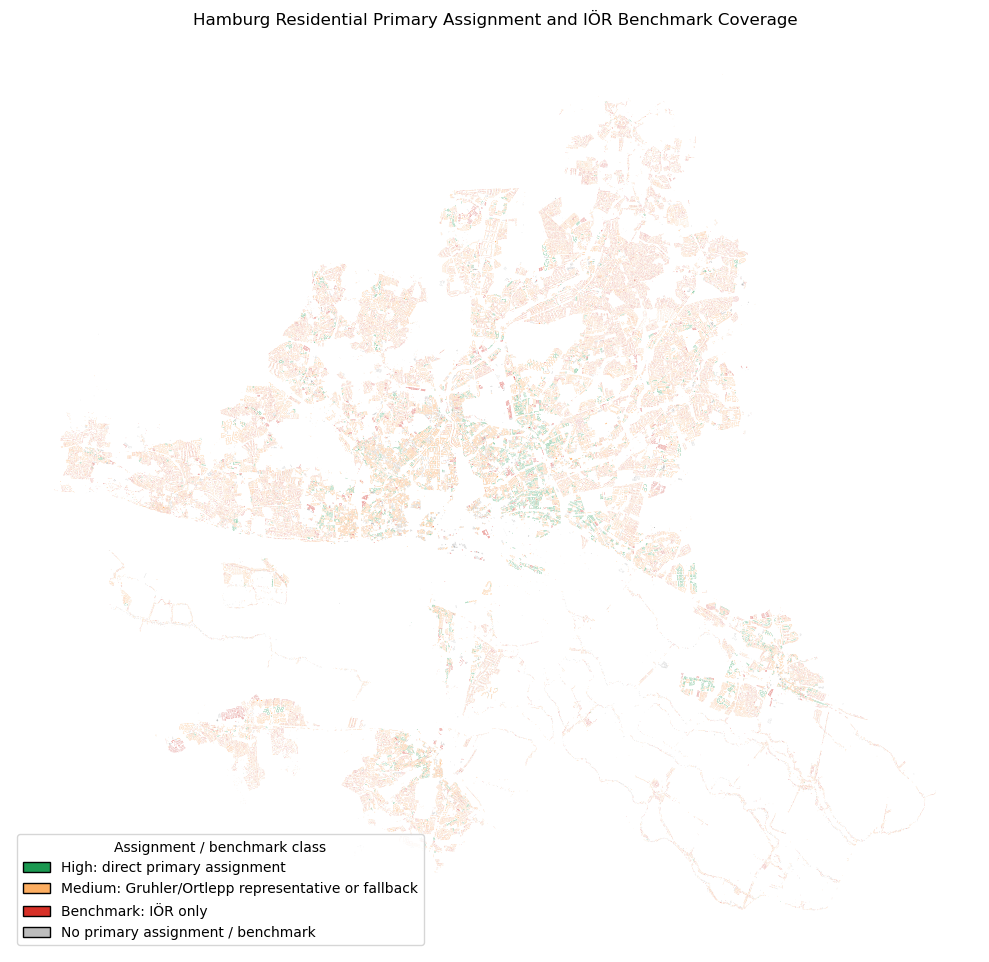

,comparison_confidence_class,label,building_count,share_of_residential_buildings_pct,estimated_gfa_m2,share_of_residential_gfa_pct,primary_material_stock_t,ioer_material_stock_t
0,benchmark_ioer_only,Benchmark: IÖR only,49142,21.62,19486641.83,14.98,0.000000e+00,2.564677e+07
1,high_direct_primary,High: direct primary assignment,7561,3.33,13323993.00,10.24,1.523786e+07,1.700316e+07
2,medium_primary_fallback_or_representative,Medium: Gruhler/Ortlepp representative or fall...,149504,65.76,82797368.00,63.65,1.560696e+08,1.068877e+08
3,uncovered_no_assignment_or_benchmark,No primary assignment / benchmark,21127,9.29,14477332.00,11.13,0.000000e+00,0.000000e+00


Output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_residential_confidence_tier_map.png


In [4]:
missing_prerequisites = [name for name in ['gdf_residential'] if name not in globals()]
if missing_prerequisites:
    raise RuntimeError(
        'Run the setup and Load Saved Results cells above first.'
        + " Missing: " + ", ".join(missing_prerequisites)
    )

confidence_class_order = [
    "high_direct_primary",
    "medium_primary_fallback_or_representative",
    "benchmark_ioer_only",
    "uncovered_no_assignment_or_benchmark",
]
confidence_class_colors = {
    "high_direct_primary": "#1a9850",
    "medium_primary_fallback_or_representative": "#fdae61",
    "benchmark_ioer_only": "#d73027",
    "uncovered_no_assignment_or_benchmark": "#bdbdbd",
}
confidence_class_labels = {
    "high_direct_primary": "High: direct primary assignment",
    "medium_primary_fallback_or_representative": "Medium: Gruhler/Ortlepp representative or fallback",
    "benchmark_ioer_only": "Benchmark: IÖR only",
    "uncovered_no_assignment_or_benchmark": "No primary assignment / benchmark",
}
medium_primary_levels = {
    "2_gruhler_candidate_average",
    "3_gruhler_fallback_average",
    "4_ortlepp_period_mfh_fallback",
}


def comparison_confidence_class(row):
    assignment_level = row.get("assignment_level")
    confidence_tier = row.get("confidence_tier")
    has_primary = bool(str(assignment_level).startswith(tuple(str(i) for i in range(1, 6)))) if pd.notna(assignment_level) else False
    has_ioer = pd.notna(row.get("ioer_total_material_stock_t"))

    if has_primary and confidence_tier == "A_direct":
        return "high_direct_primary"
    if has_primary and (assignment_level in medium_primary_levels or confidence_tier in {"B_representative", "C_fallback"}):
        return "medium_primary_fallback_or_representative"
    if (not has_primary) and has_ioer:
        return "benchmark_ioer_only"
    return "uncovered_no_assignment_or_benchmark"


plot_gdf = gdf_residential.copy()
plot_gdf["comparison_confidence_class"] = plot_gdf.apply(comparison_confidence_class, axis=1)
plot_gdf["map_color"] = plot_gdf["comparison_confidence_class"].map(confidence_class_colors).fillna("#bdbdbd")
plot_gdf = plot_gdf[plot_gdf.geometry.notna() & ~plot_gdf.geometry.is_empty].copy()

fig, ax = plt.subplots(figsize=(10, 10))
plot_gdf.plot(
    ax=ax,
    color=plot_gdf["map_color"],
    linewidth=0.03,
    edgecolor="white",
)

handles = [
    Patch(facecolor=confidence_class_colors[class_name], edgecolor="black", label=confidence_class_labels[class_name])
    for class_name in confidence_class_order
    if class_name in set(plot_gdf["comparison_confidence_class"])
]
ax.legend(handles=handles, title="Assignment / benchmark class", loc="lower left", frameon=True)
ax.set_title("Hamburg Residential Primary Assignment and IÖR Benchmark Coverage")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(CONFIDENCE_TIER_MAP_PATH, dpi=600, bbox_inches="tight")
plt.show()

comparison_confidence_summary = (
    plot_gdf
    .groupby("comparison_confidence_class", dropna=False)
    .agg(
        building_count=("comparison_confidence_class", "size"),
        estimated_gfa_m2=("estimated_gfa_m2", "sum"),
        primary_material_stock_t=("total_material_stock_t", "sum"),
        ioer_material_stock_t=("ioer_total_material_stock_t", "sum"),
    )
    .reset_index()
)
comparison_confidence_summary["label"] = comparison_confidence_summary["comparison_confidence_class"].map(confidence_class_labels)
comparison_confidence_summary["share_of_residential_buildings_pct"] = (comparison_confidence_summary["building_count"] / len(gdf_residential) * 100).round(2)
comparison_confidence_summary["share_of_residential_gfa_pct"] = (comparison_confidence_summary["estimated_gfa_m2"] / gdf_residential["estimated_gfa_m2"].sum(skipna=True) * 100).round(2)
display(comparison_confidence_summary[[
    "comparison_confidence_class",
    "label",
    "building_count",
    "share_of_residential_buildings_pct",
    "estimated_gfa_m2",
    "share_of_residential_gfa_pct",
    "primary_material_stock_t",
    "ioer_material_stock_t",
]])

print("Output:", CONFIDENCE_TIER_MAP_PATH)


This grid heatmap uses the primary typology confidence scale only: `A_direct = 4`, `B_representative = 3`, `C_fallback = 2`, and `D_unassigned = 0`. IÖR benchmark coverage is not part of the primary confidence score and is summarised separately as benchmark-only share.


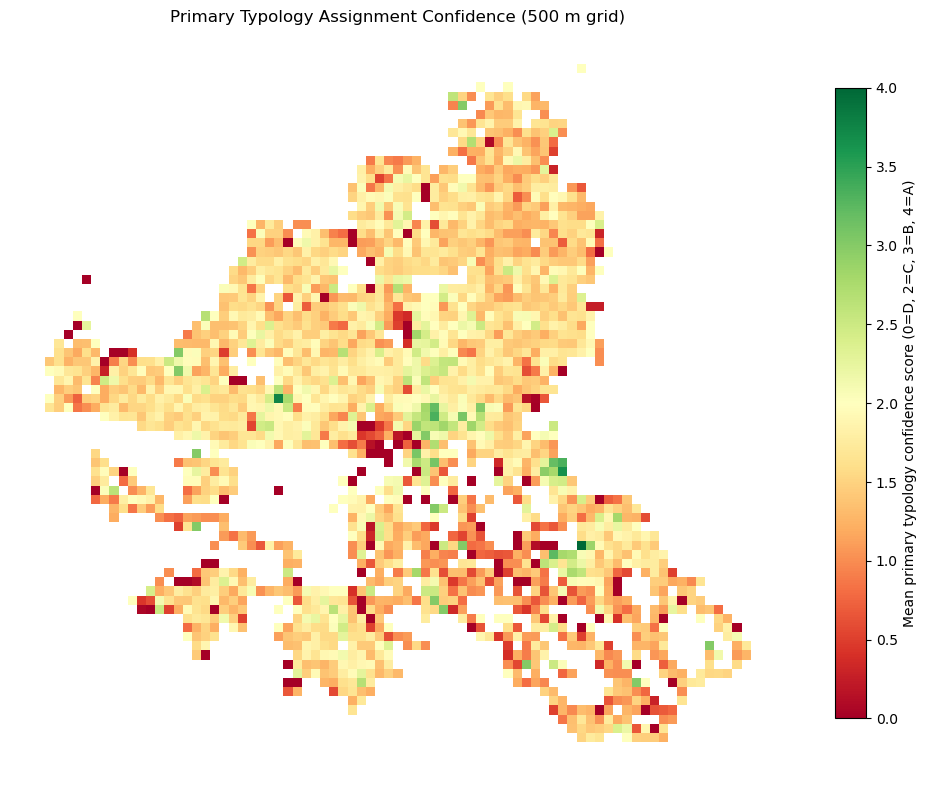

Confidence heatmap output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_residential_confidence_tier_heatmap.png


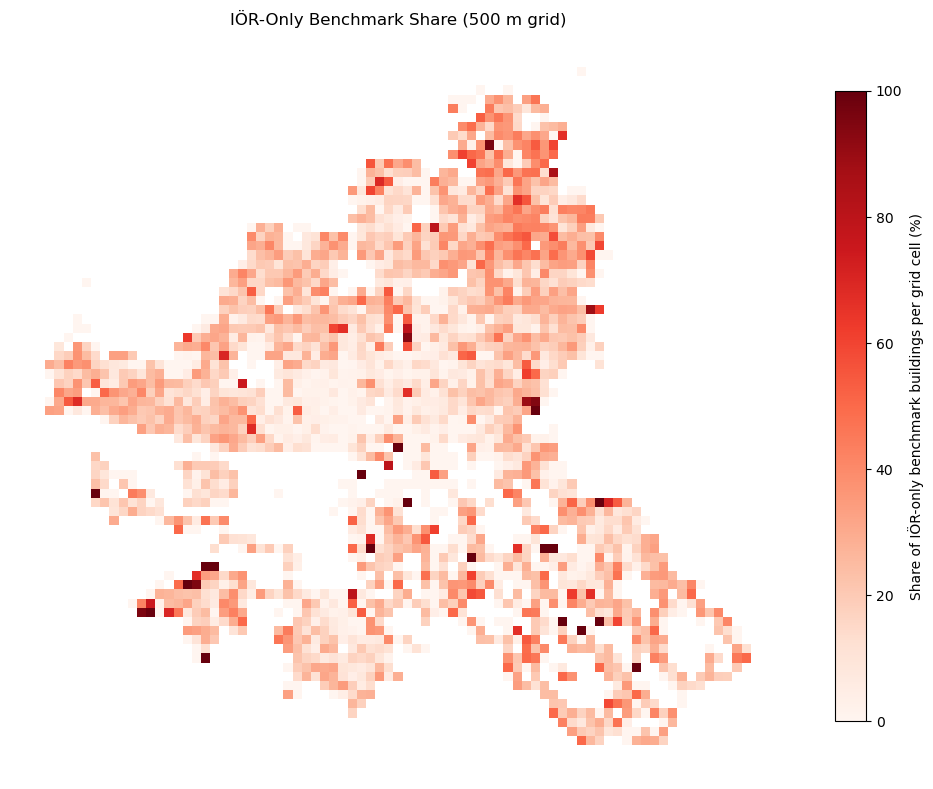

IÖR-only benchmark heatmap output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_residential_low_confidence_share_heatmap.png
Grid cells: 2238
Grid size (m): 500


,building_count,mean_confidence_score,median_confidence_score,ioer_benchmark_only_share_pct,medium_confidence_share_pct,high_confidence_share_pct,uncovered_share_pct
count,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000,2238.000000
mean,101.579088,1.498094,1.650357,19.908188,60.841557,3.648101,35.510342
std,96.512581,0.558338,0.833114,17.392386,21.788705,9.141146,22.560129
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.250000,2.000000,6.126924,50.794766,0.000000,20.327539
50%,72.000000,1.533333,2.000000,18.047230,63.029193,0.000000,33.333333
75%,164.000000,1.810608,2.000000,28.571429,74.359232,2.602476,45.792519
max,684.000000,4.000000,4.000000,100.000000,100.000000,100.000000,100.000000


In [5]:
missing_prerequisites = [name for name in ['gdf_residential', 'comparison_confidence_class', 'PRIMARY_CONFIDENCE_SCORE_MAP'] if name not in globals()]
if missing_prerequisites:
    raise RuntimeError(
        'Run the setup, Load Saved Results, and preceding precision-tier map cells first.'
        + " Missing: " + ", ".join(missing_prerequisites)
    )

GRID_SIZE_M = 500
MIN_BUILDINGS_PER_CELL = 1

heatmap_points = gdf_residential.copy()
heatmap_points["comparison_confidence_class"] = heatmap_points.apply(comparison_confidence_class, axis=1)
heatmap_points["confidence_score"] = heatmap_points["confidence_tier"].map(PRIMARY_CONFIDENCE_SCORE_MAP)
heatmap_points = heatmap_points[heatmap_points["confidence_score"].notna()].copy()

heatmap_points["ioer_benchmark_only"] = heatmap_points["comparison_confidence_class"].eq("benchmark_ioer_only").astype(int)
heatmap_points["medium_confidence"] = heatmap_points["confidence_tier"].isin(["B_representative", "C_fallback"]).astype(int)
heatmap_points["high_confidence"] = heatmap_points["confidence_tier"].eq("A_direct").astype(int)
heatmap_points["uncovered"] = heatmap_points["confidence_tier"].eq("D_unassigned").astype(int)

representative_points = heatmap_points.geometry.representative_point()
heatmap_points["grid_x"] = (representative_points.x // GRID_SIZE_M * GRID_SIZE_M).astype(int)
heatmap_points["grid_y"] = (representative_points.y // GRID_SIZE_M * GRID_SIZE_M).astype(int)

grid_summary = (
    heatmap_points
    .groupby(["grid_x", "grid_y"], dropna=False)
    .agg(
        building_count=("confidence_score", "size"),
        mean_confidence_score=("confidence_score", "mean"),
        median_confidence_score=("confidence_score", "median"),
        ioer_benchmark_only_share=("ioer_benchmark_only", "mean"),
        medium_confidence_share=("medium_confidence", "mean"),
        high_confidence_share=("high_confidence", "mean"),
        uncovered_share=("uncovered", "mean"),
    )
    .reset_index()
)
grid_summary = grid_summary[grid_summary["building_count"] >= MIN_BUILDINGS_PER_CELL].copy()
grid_summary["ioer_benchmark_only_share_pct"] = grid_summary["ioer_benchmark_only_share"] * 100
grid_summary["medium_confidence_share_pct"] = grid_summary["medium_confidence_share"] * 100
grid_summary["high_confidence_share_pct"] = grid_summary["high_confidence_share"] * 100
grid_summary["uncovered_share_pct"] = grid_summary["uncovered_share"] * 100

grid_summary["geometry"] = grid_summary.apply(
    lambda row: box(
        row["grid_x"],
        row["grid_y"],
        row["grid_x"] + GRID_SIZE_M,
        row["grid_y"] + GRID_SIZE_M,
    ),
    axis=1,
)
grid_gdf = gpd.GeoDataFrame(grid_summary, geometry="geometry", crs=gdf_residential.crs)

fig, ax = plt.subplots(figsize=(10, 10))
grid_gdf.plot(
    column="mean_confidence_score",
    ax=ax,
    cmap="RdYlGn",
    linewidth=0,
    edgecolor="none",
    legend=False,
    vmin=0,
    vmax=4,
    rasterized=True,
)

sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=4), cmap="RdYlGn")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.65)
cbar.set_label("Mean primary typology confidence score (0=D, 2=C, 3=B, 4=A)")

ax.set_title(f"Primary Typology Assignment Confidence ({GRID_SIZE_M} m grid)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(CONFIDENCE_TIER_HEATMAP_PATH, dpi=600, bbox_inches="tight")
plt.show()

print("Confidence heatmap output:", CONFIDENCE_TIER_HEATMAP_PATH)

fig, ax = plt.subplots(figsize=(10, 10))
grid_gdf.plot(
    column="ioer_benchmark_only_share_pct",
    ax=ax,
    cmap="Reds",
    linewidth=0,
    edgecolor="none",
    legend=False,
    vmin=0,
    vmax=100,
    rasterized=True,
)

sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=0, vmax=100), cmap="Reds")
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.65)
cbar.set_label("Share of IÖR-only benchmark buildings per grid cell (%)")

ax.set_title(f"IÖR-Only Benchmark Share ({GRID_SIZE_M} m grid)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(LOW_CONFIDENCE_SHARE_HEATMAP_PATH, dpi=600, bbox_inches="tight")
plt.show()

print("IÖR-only benchmark heatmap output:", LOW_CONFIDENCE_SHARE_HEATMAP_PATH)
print("Grid cells:", len(grid_gdf))
print("Grid size (m):", GRID_SIZE_M)
grid_gdf[[
    "building_count",
    "mean_confidence_score",
    "median_confidence_score",
    "ioer_benchmark_only_share_pct",
    "medium_confidence_share_pct",
    "high_confidence_share_pct",
    "uncovered_share_pct",
]].describe()


## Statistical Summary: Assignment Levels and Confidence Tiers

### Confidence Tier Achievement Counts

In [6]:
confidence_tier_descriptions = {
    "A_direct": "A - Direct assignment",
    "B_representative": "B - Representative assignment",
    "C_fallback": "C - Fallback assignment",
    "D_unassigned": "D - No primary assignment",
}

confidence_tier_achievement_summary = (
    gdf_residential["confidence_tier"]
    .value_counts(dropna=False)
    .reindex(PRIMARY_CONFIDENCE_TIER_ORDER, fill_value=0)
    .rename_axis("confidence_tier")
    .reset_index(name="building_count")
)
confidence_tier_achievement_summary["tier_summary"] = confidence_tier_achievement_summary["confidence_tier"].map(confidence_tier_descriptions)
confidence_tier_achievement_summary["share_of_residential_buildings_pct"] = (
    confidence_tier_achievement_summary["building_count"] / len(gdf_residential) * 100
).round(2)

display(confidence_tier_achievement_summary[[
    "tier_summary",
    "confidence_tier",
    "building_count",
    "share_of_residential_buildings_pct",
]])


,tier_summary,confidence_tier,building_count,share_of_residential_buildings_pct
0,A - Direct assignment,A_direct,7561,3.33
1,B - Representative assignment,B_representative,31224,13.73
2,C - Fallback assignment,C_fallback,118280,52.03
3,D - No primary assignment,D_unassigned,70269,30.91


In [7]:
print("Assignment-level summary")
display(assignment_summary)

print("Confidence-tier summary")
confidence_summary


Assignment-level summary


,assignment_level,building_count,residential_buildings,total_estimated_gfa_m2,residential_estimated_gfa_m2,total_material_stock_t,share_of_all_buildings_pct,share_of_residential_buildings_pct,share_of_residential_estimated_gfa_pct,share_of_assigned_material_stock_pct
0,not_residential_no_material_intensity,151986,0,89989930.00,0.00,0.000000e+00,40.07,0.00,0.00,0.00
1,3_gruhler_fallback_average,75118,75118,19910583.00,19910583.00,2.503781e+07,19.80,33.04,15.31,14.62
2,unresolved_no_material_intensity,70269,70269,33963973.83,33963973.83,0.000000e+00,18.52,30.91,26.11,0.00
3,4_ortlepp_period_mfh_fallback,41534,41534,46461742.00,46461742.00,1.035617e+08,10.95,18.27,35.72,60.45
4,1_gruhler_specific_typology,23231,23231,17968763.00,17968763.00,2.192281e+07,6.12,10.22,13.81,12.80
5,2_gruhler_candidate_average,9999,9999,7955438.00,7955438.00,1.156659e+07,2.64,4.40,6.12,6.75
6,5_ortlepp_general_mfh_average,7183,7183,3824835.00,3824835.00,9.218617e+06,1.89,3.16,2.94,5.38


Confidence-tier summary


,confidence_tier,building_count,residential_buildings,total_estimated_gfa_m2,residential_estimated_gfa_m2,total_material_stock_t,share_of_all_buildings_pct,share_of_residential_buildings_pct,share_of_residential_estimated_gfa_pct,share_of_assigned_material_stock_pct,confidence_label
0,D_unassigned,222255,70269,1.239539e+08,33963973.83,0.000000e+00,58.59,30.91,26.11,0.00,D - Unassigned
1,C_fallback,118280,118280,7.337475e+07,73374750.00,1.433815e+08,31.18,52.03,56.41,83.70,C - Fallback estimate
2,B_representative,31224,31224,9.422618e+06,9422618.00,1.268811e+07,8.23,13.73,7.24,7.41,B - Representative match
3,A_direct,7561,7561,1.332399e+07,13323993.00,1.523786e+07,1.99,3.33,10.24,8.90,A - Direct match


## Statistical Summary: Residential Stock by Confidence Tier

In [8]:
primary_confidence_gdf = gdf_residential[gdf_residential["confidence_tier"].isin(PRIMARY_CONFIDENCE_TIER_ORDER)].copy()
primary_assigned_mask = primary_confidence_gdf["confidence_tier"].isin(["A_direct", "B_representative", "C_fallback"])
assigned_residential_count = int(primary_assigned_mask.sum())

stock_by_confidence_tier = (
    primary_confidence_gdf
    .groupby("confidence_tier", dropna=False)
    .agg(
        building_count=("confidence_tier", "size"),
        estimated_gfa_m2=("estimated_gfa_m2", "sum"),
        total_material_stock_t=("total_material_stock_t", "sum"),
        median_building_stock_t=("total_material_stock_t", "median"),
        mean_building_stock_t=("total_material_stock_t", "mean"),
        median_gfa_m2=("estimated_gfa_m2", "median"),
        mean_gfa_m2=("estimated_gfa_m2", "mean"),
    )
    .reindex(PRIMARY_CONFIDENCE_TIER_ORDER, fill_value=0)
    .rename_axis("confidence_tier")
    .reset_index()
)
stock_by_confidence_tier["confidence_label"] = stock_by_confidence_tier["confidence_tier"].map(CONFIDENCE_TIER_LABELS)
stock_by_confidence_tier["share_of_residential_buildings_pct"] = (
    stock_by_confidence_tier["building_count"] / len(primary_confidence_gdf) * 100
).round(2)
stock_by_confidence_tier["share_of_assigned_residential_buildings_pct"] = 0.0
if assigned_residential_count > 0:
    stock_by_confidence_tier["share_of_assigned_residential_buildings_pct"] = (
        stock_by_confidence_tier["building_count"] / assigned_residential_count * 100
    ).round(2)
stock_by_confidence_tier.loc[stock_by_confidence_tier["confidence_tier"].eq("D_unassigned"), "share_of_assigned_residential_buildings_pct"] = 0.0
stock_by_confidence_tier["share_of_residential_gfa_pct"] = (
    stock_by_confidence_tier["estimated_gfa_m2"] / stock_by_confidence_tier["estimated_gfa_m2"].sum() * 100
).round(2)
stock_by_confidence_tier["share_of_material_stock_pct"] = (
    stock_by_confidence_tier["total_material_stock_t"] / stock_by_confidence_tier["total_material_stock_t"].sum() * 100
).round(2)

confidence_reporting_table = stock_by_confidence_tier[[
    "confidence_tier",
    "confidence_label",
    "building_count",
    "share_of_residential_buildings_pct",
    "share_of_assigned_residential_buildings_pct",
]].copy()
display(confidence_reporting_table)
stock_by_confidence_tier


stock_intensity_mask = (
    gdf_residential["total_material_stock_t"].notna()
    & gdf_residential["total_material_stock_t"].gt(0)
    & gdf_residential["estimated_gfa_m2"].notna()
    & gdf_residential["estimated_gfa_m2"].gt(0)
)
age_intensity_gdf = gdf_residential.loc[stock_intensity_mask].copy()
age_intensity_gdf["building_material_intensity_kg_m2"] = (
    age_intensity_gdf["total_material_stock_t"] * 1000 / age_intensity_gdf["estimated_gfa_m2"]
)

construction_period_bins = [0, 1918, 1948, 1978, 1990, 2002, 2011, 2026]
construction_period_labels = ["<=1918", "1919-1948", "1949-1978", "1979-1990", "1991-2002", "2003-2011", "2012-2026"]
construction_period = pd.cut(
    age_intensity_gdf["construction_year_used_for_assignment"],
    bins=construction_period_bins,
    labels=construction_period_labels,
    right=True,
    include_lowest=True,
)
age_intensity_gdf["construction_period"] = construction_period.astype("object").where(construction_period.notna(), "Unknown year")
construction_period_order = construction_period_labels + ["Unknown year"]

material_intensity_by_age = (
    age_intensity_gdf
    .groupby("construction_period", dropna=False)
    .agg(
        building_count=("total_material_stock_t", "size"),
        estimated_gfa_m2=("estimated_gfa_m2", "sum"),
        total_material_stock_t=("total_material_stock_t", "sum"),
        median_building_intensity_kg_m2=("building_material_intensity_kg_m2", "median"),
        mean_building_intensity_kg_m2=("building_material_intensity_kg_m2", "mean"),
    )
    .reindex(construction_period_order)
    .dropna(how="all")
    .reset_index()
)
material_intensity_by_age["area_weighted_intensity_kg_m2"] = (
    material_intensity_by_age["total_material_stock_t"] * 1000 / material_intensity_by_age["estimated_gfa_m2"]
)
material_intensity_by_age["share_of_valid_stock_buildings_pct"] = (
    material_intensity_by_age["building_count"] / material_intensity_by_age["building_count"].sum() * 100
).round(2)
material_intensity_by_age["share_of_material_stock_pct"] = (
    material_intensity_by_age["total_material_stock_t"] / material_intensity_by_age["total_material_stock_t"].sum() * 100
).round(2)
material_intensity_by_age = material_intensity_by_age[[
    "construction_period",
    "building_count",
    "share_of_valid_stock_buildings_pct",
    "estimated_gfa_m2",
    "total_material_stock_t",
    "share_of_material_stock_pct",
    "area_weighted_intensity_kg_m2",
    "median_building_intensity_kg_m2",
    "mean_building_intensity_kg_m2",
]].round({
    "estimated_gfa_m2": 0,
    "total_material_stock_t": 0,
    "area_weighted_intensity_kg_m2": 1,
    "median_building_intensity_kg_m2": 1,
    "mean_building_intensity_kg_m2": 1,
})
material_intensity_by_age.to_csv(MATERIAL_INTENSITY_BY_AGE_PATH, index=False)

display(material_intensity_by_age)
print("Material intensity by construction period output:", MATERIAL_INTENSITY_BY_AGE_PATH)


cascade_assignment_mask = gdf_residential["assignment_level"].fillna("").astype("string").str.match(r"^[1-5]_")
cascade_stock_mask = gdf_residential["total_material_stock_t"].notna()
ioer_stock_mask = gdf_residential.get("ioer_total_material_stock_t", pd.Series(pd.NA, index=gdf_residential.index)).notna()
common_cascade_ioer_mask = cascade_stock_mask & ioer_stock_mask

comparison_totals = pd.DataFrame([
    {
        "comparison_scope": "cascade_stock_estimate",
        "building_count": int(cascade_stock_mask.sum()),
        "cascade_assignment_count": int(cascade_assignment_mask.sum()),
        "estimated_gfa_m2": gdf_residential.loc[cascade_stock_mask, "estimated_gfa_m2"].sum(skipna=True),
        "cascade_material_stock_t": gdf_residential.loc[cascade_stock_mask, "total_material_stock_t"].sum(skipna=True),
        "ioer_material_stock_t": pd.NA,
    },
    {
        "comparison_scope": "ortlepp_sensitivity",
        "building_count": int(gdf_residential["ortlepp_variant_material_total_t"].notna().sum()) if "ortlepp_variant_material_total_t" in gdf_residential.columns else 0,
        "cascade_assignment_count": pd.NA,
        "estimated_gfa_m2": gdf_residential.loc[gdf_residential.get("ortlepp_variant_material_total_t", pd.Series(pd.NA, index=gdf_residential.index)).notna(), "estimated_gfa_m2"].sum(skipna=True),
        "cascade_material_stock_t": pd.NA,
        "ioer_material_stock_t": pd.NA,
        "ortlepp_material_stock_t": gdf_residential.get("ortlepp_variant_material_total_t", pd.Series(dtype="float64")).sum(skipna=True),
    },
    {
        "comparison_scope": "ioer_benchmark",
        "building_count": int(ioer_stock_mask.sum()),
        "cascade_assignment_count": pd.NA,
        "estimated_gfa_m2": gdf_residential.loc[ioer_stock_mask, "estimated_gfa_m2"].sum(skipna=True),
        "cascade_material_stock_t": pd.NA,
        "ioer_material_stock_t": gdf_residential.loc[ioer_stock_mask, "ioer_total_material_stock_t"].sum(skipna=True),
    },
    {
        "comparison_scope": "common_cascade_and_ioer",
        "building_count": int(common_cascade_ioer_mask.sum()),
        "cascade_assignment_count": int((cascade_assignment_mask & ioer_stock_mask).sum()),
        "estimated_gfa_m2": gdf_residential.loc[common_cascade_ioer_mask, "estimated_gfa_m2"].sum(skipna=True),
        "cascade_material_stock_t": gdf_residential.loc[common_cascade_ioer_mask, "total_material_stock_t"].sum(skipna=True),
        "ioer_material_stock_t": gdf_residential.loc[common_cascade_ioer_mask, "ioer_total_material_stock_t"].sum(skipna=True),
    },
])
for comparison_column in ["cascade_material_stock_t", "ioer_material_stock_t", "ortlepp_material_stock_t"]:
    if comparison_column in comparison_totals.columns:
        comparison_totals[comparison_column] = pd.to_numeric(comparison_totals[comparison_column], errors="coerce")

comparison_totals["ioer_minus_cascade_t"] = comparison_totals["ioer_material_stock_t"] - comparison_totals["cascade_material_stock_t"]
comparison_totals["ioer_vs_cascade_pct"] = (
    comparison_totals["ioer_minus_cascade_t"] / comparison_totals["cascade_material_stock_t"] * 100
).round(2)

display(comparison_totals)

overlap_building_count = int(common_cascade_ioer_mask.sum())
overlap_primary_total_t = gdf_residential.loc[common_cascade_ioer_mask, "total_material_stock_t"].sum(skipna=True)
overlap_ioer_total_t = gdf_residential.loc[common_cascade_ioer_mask, "ioer_total_material_stock_t"].sum(skipna=True)
overlap_difference_t = overlap_ioer_total_t - overlap_primary_total_t
overlap_difference_pct = overlap_difference_t / overlap_primary_total_t * 100 if overlap_primary_total_t > 0 else pd.NA

defensible_benchmark_comparison = pd.DataFrame(
    {
        "metric": [
            "Number of identical buildings",
            "Total material stock (Mt)",
            "Mean stock per building (t/building)",
        ],
        "Primary cascade assignment": [
            overlap_building_count,
            overlap_primary_total_t / 1_000_000,
            overlap_primary_total_t / overlap_building_count if overlap_building_count > 0 else pd.NA,
        ],
        "IÖR benchmark": [
            overlap_building_count,
            overlap_ioer_total_t / 1_000_000,
            overlap_ioer_total_t / overlap_building_count if overlap_building_count > 0 else pd.NA,
        ],
    }
)
defensible_benchmark_difference = pd.DataFrame([
    {
        "metric": "Difference, IÖR minus primary",
        "difference_t": overlap_difference_t,
        "difference_Mt": overlap_difference_t / 1_000_000,
        "difference_pct_of_primary": round(overlap_difference_pct, 2) if pd.notna(overlap_difference_pct) else pd.NA,
    }
])

display(defensible_benchmark_comparison)
display(defensible_benchmark_difference)

ioer_variant_type_summary = (
    gdf_residential[gdf_residential["ioer_variant_type"].notna() & gdf_residential["ioer_variant_type"].ne("")]
    .assign(
        has_cascade_assignment=lambda df: df["assignment_level"].fillna("").astype("string").str.match(r"^[1-5]_"),
        has_ioer_stock=lambda df: df["ioer_total_material_stock_t"].notna(),
        has_cascade_stock=lambda df: df["total_material_stock_t"].notna(),
    )
    .groupby("ioer_variant_type", dropna=False)
    .agg(
        buildings_with_variant_type=("ioer_variant_type", "size"),
        buildings_with_cascade_assignment=("has_cascade_assignment", "sum"),
        buildings_with_ioer_stock=("has_ioer_stock", "sum"),
        buildings_with_cascade_stock=("has_cascade_stock", "sum"),
        estimated_gfa_m2=("estimated_gfa_m2", "sum"),
        ioer_material_stock_t=("ioer_total_material_stock_t", "sum"),
        cascade_material_stock_t=("total_material_stock_t", "sum"),
    )
    .reset_index()
)
ioer_variant_type_summary["ioer_t_per_m2"] = ioer_variant_type_summary["ioer_material_stock_t"] / ioer_variant_type_summary["estimated_gfa_m2"]
ioer_variant_type_summary["ioer_minus_cascade_t"] = ioer_variant_type_summary["ioer_material_stock_t"] - ioer_variant_type_summary["cascade_material_stock_t"]
display(ioer_variant_type_summary)


,confidence_tier,confidence_label,building_count,share_of_residential_buildings_pct,share_of_assigned_residential_buildings_pct
0,A_direct,A - Direct match,7561,3.33,4.81
1,B_representative,B - Representative match,31224,13.73,19.88
2,C_fallback,C - Fallback estimate,118280,52.03,75.31
3,D_unassigned,D - Unassigned,70269,30.91,0.00


,construction_period,building_count,share_of_valid_stock_buildings_pct,estimated_gfa_m2,total_material_stock_t,share_of_material_stock_pct,area_weighted_intensity_kg_m2,median_building_intensity_kg_m2,mean_building_intensity_kg_m2
0,<=1918,1951.0,1.24,2351391.0,6293603.0,3.67,2676.5,2813.0,2719.2
1,1919-1948,2424.0,1.54,2617775.0,6497829.0,3.79,2482.2,2739.0,2588.6
2,1949-1978,39817.0,25.36,44924811.0,84590190.0,49.38,1882.9,2176.0,1813.0
3,1979-1990,11608.0,7.39,9957198.0,17628419.0,10.29,1770.4,2107.0,1756.3
4,1991-2002,13862.0,8.83,9321733.0,15335939.0,8.95,1645.2,1510.2,1565.8
5,2003-2011,5071.0,3.23,3213035.0,6705105.0,3.91,2086.8,2216.0,2154.8
6,Unknown year,82292.0,52.41,23735418.0,34256425.0,20.00,1443.3,1272.8,1350.9


Material intensity by construction period output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/data/processed/hamburg_material_intensity_by_construction_period.csv


,comparison_scope,building_count,cascade_assignment_count,estimated_gfa_m2,cascade_material_stock_t,ioer_material_stock_t,ortlepp_material_stock_t,ioer_minus_cascade_t,ioer_vs_cascade_pct
0,cascade_stock_estimate,157025,157065,9.612136e+07,1.713075e+08,NaN,NaN,NaN,NaN
1,ortlepp_sensitivity,82391,<NA>,7.746453e+07,NaN,NaN,1.736183e+08,NaN,NaN
2,ioer_benchmark,206167,<NA>,1.156080e+08,NaN,1.495376e+08,NaN,NaN,NaN
3,common_cascade_and_ioer,157025,157025,9.612136e+07,1.713075e+08,1.238909e+08,NaN,-4.741665e+07,-27.68


,metric,Primary cascade assignment,IÖR benchmark
0,Number of identical buildings,157025.000000,157025.000000
1,Total material stock (Mt),171.307510,123.890862
2,Mean stock per building (t/building),1090.956917,788.988137


,metric,difference_t,difference_Mt,difference_pct_of_primary
0,"Difference, IÖR minus primary",-4.741665e+07,-47.416648,-27.68


,ioer_variant_type,buildings_with_variant_type,buildings_with_cascade_assignment,buildings_with_ioer_stock,buildings_with_cascade_stock,estimated_gfa_m2,ioer_material_stock_t,cascade_material_stock_t,ioer_t_per_m2,ioer_minus_cascade_t
0,IÖR_EFH_Hamburg,116602,74634,116485,74634,30090606.83,4.046490e+07,2.465789e+07,1.344768,1.580701e+07
1,IÖR_MFH_Hamburg,89722,82431,89682,82391,85517396.00,1.090727e+08,1.466496e+08,1.275445,-3.757689e+07


## Statistical Summary: Material Totals

In [9]:
material_stock_totals = []
for col in stock_t_columns:
    material = col.replace("_stock_t", "")
    total_stock_t = pd.to_numeric(gdf_residential[col], errors="coerce").sum(skipna=True)
    material_stock_totals.append({
        "material": material,
        "total_stock_t": total_stock_t,
    })
material_stock_totals = pd.DataFrame(material_stock_totals)
material_stock_totals = material_stock_totals[material_stock_totals["total_stock_t"].notna()].copy()
material_stock_total = material_stock_totals["total_stock_t"].sum()
material_stock_totals["share_of_total_material_stock_pct"] = 0.0
if material_stock_total > 0:
    material_stock_totals["share_of_total_material_stock_pct"] = (
        material_stock_totals["total_stock_t"] / material_stock_total * 100
    ).round(2)
material_stock_totals.sort_values("total_stock_t", ascending=False).head(20)


,material,total_stock_t,share_of_total_material_stock_pct
0,ioer_total_material,1.495376e+08,46.61
7,concrete,7.517653e+07,23.43
10,brick,4.591043e+07,14.31
13,plaster_board_gypsum,1.849763e+07,5.77
11,mortar_plaster,1.221356e+07,3.81
3,unspecified_metal,7.450762e+06,2.32
12,mineral_fill,5.621380e+06,1.75
31,other_unspecified_material,3.066428e+06,0.96
4,wood,1.942986e+06,0.61
30,insulation_unspecified,1.336642e+06,0.42


## Statistical Summary: Quality Flags

In [10]:
quality_flags_text = gdf_residential.get("quality_flags", pd.Series("", index=gdf_residential.index)).fillna("").astype("string")
quality_flag_rows = []
for flags in quality_flags_text:
    for flag in str(flags).split(";"):
        if flag:
            quality_flag_rows.append(flag)

quality_flags_summary_from_buildings = (
    pd.Series(quality_flag_rows, name="quality_flag")
    .value_counts()
    .rename_axis("quality_flag")
    .reset_index(name="building_count")
)
if quality_flags_summary_from_buildings.empty:
    quality_flags_reporting_table = pd.DataFrame(columns=["quality_flag", "building_count", "share_of_residential_buildings_pct"])
else:
    quality_flags_reporting_table = quality_flags_summary_from_buildings.copy()
    quality_flags_reporting_table["share_of_residential_buildings_pct"] = (
        quality_flags_reporting_table["building_count"] / len(gdf_residential) * 100
    ).round(2)

display(quality_flags_reporting_table.head(30))


,quality_flag,building_count,share_of_residential_buildings_pct
0,year_missing,96403,42.41
1,gruhler_fallback_used,75118,33.04
2,ortlepp_fallback_used,48717,21.43
3,bauweise_missing,20833,9.16
4,attic_proxy_used,13590,5.98
5,two_storey_sfh_extension,13429,5.91
6,candidate_average_used,9999,4.40
7,roof_unknown,9295,4.09
8,year_multiple_earliest_used,7291,3.21
9,roof_not_in_csv_assignment_groups,5038,2.22


## Cross-Tabs: Form, Year Quality, and Precision

In [11]:
if "confidence_tier" not in gdf_residential.columns:
    raise KeyError("Expected column 'confidence_tier' is missing. Rerun 05_typology_assignment_revised.ipynb to regenerate the residential results.")

candidate_form_columns = [
    "bauweise_group",
    "building_form_class",
    "bauweise_direct_form",
    "bauweise_code_clean",
    "bauweise_code",
]
form_column = next((column for column in candidate_form_columns if column in gdf_residential.columns), None)

if form_column is None:
    print("No building-form column available for cross-tab. Checked:", candidate_form_columns)
else:
    print(f"{form_column} by confidence tier")
    display(pd.crosstab(
        gdf_residential[form_column].fillna("missing"),
        gdf_residential["confidence_tier"].fillna("missing"),
        margins=True,
    ))

if "construction_year_status" in gdf_residential.columns:
    print("Construction year status by confidence tier")
    display(pd.crosstab(
        gdf_residential["construction_year_status"].fillna("missing"),
        gdf_residential["confidence_tier"].fillna("missing"),
        margins=True,
    ))
else:
    print("No construction_year_status column available for cross-tab.")

if "assignment_reference_kind" in gdf_residential.columns:
    print("Reference kind by confidence tier")
    display(pd.crosstab(
        gdf_residential["assignment_reference_kind"].fillna("missing"),
        gdf_residential["confidence_tier"].fillna("missing"),
        margins=True,
    ))


bauweise_group by confidence tier


confidence_tier,A_direct,B_representative,C_fallback,D_unassigned,All
bauweise_group,,,,,
detached_sfh,458,20748,38975,23793,83974
mfh,6928,116,22790,3133,32967
row_terraced_grouped_sfh,175,6758,45664,4158,56755
semi_detached_sfh,0,3602,10851,18175,32628
unknown_or_out_of_scope,0,0,0,21010,21010
All,7561,31224,118280,70269,227334


Construction year status by confidence tier


confidence_tier,A_direct,B_representative,C_fallback,D_unassigned,All
construction_year_status,,,,,
invalid_or_unusable,0,0,1,0,1
invalid_placeholder_1500,0,334,1315,114,1763
missing,0,10446,70205,15752,96403
multiple_years_earliest_used,104,986,1281,4920,7291
single_year,7457,19458,45478,49483,121876
All,7561,31224,118280,70269,227334


Reference kind by confidence tier


confidence_tier,A_direct,B_representative,C_fallback,D_unassigned,All
assignment_reference_kind,,,,,
,0,0,0,70269,70269
single_typology,7561,15670,41534,0,64765
unweighted_average,0,15554,76746,0,92300
All,7561,31224,118280,70269,227334


## Map: Total Stock with Precision Context

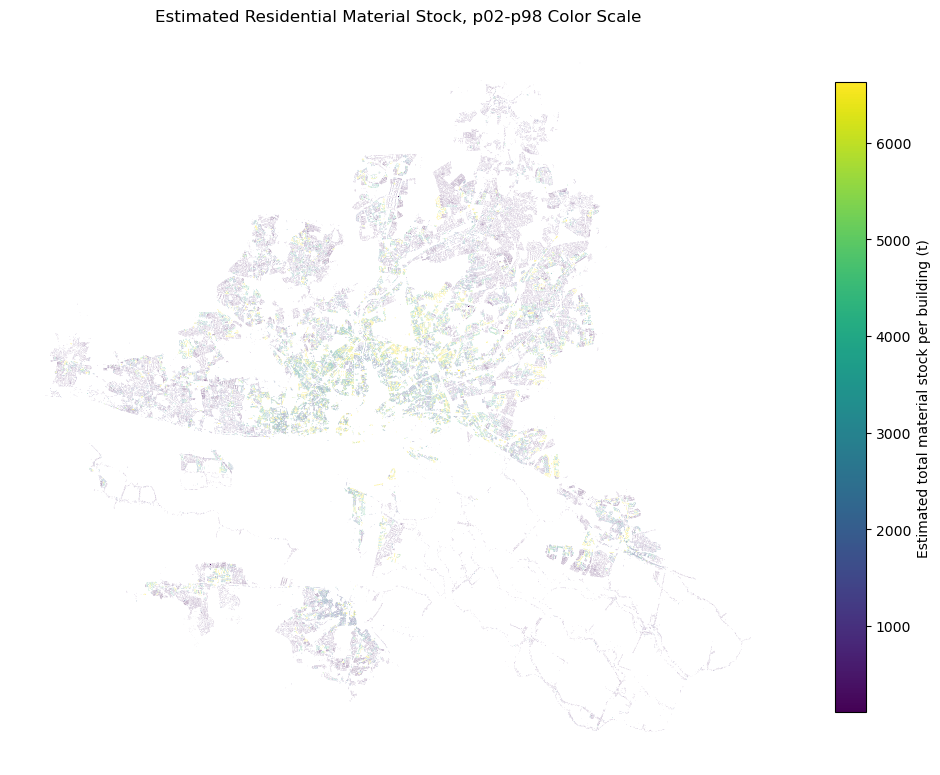

Output: /Users/rirarum/Documents/REAP/Thesis/URBAN MINE HH/results/maps/hamburg_residential_total_stock_by_confidence_tier_map.png
Color scale p02-p98 (t): 103.1 - 6630.5


In [12]:
plot_gdf = gdf_residential.copy()
plot_gdf["total_material_stock_t"] = pd.to_numeric(plot_gdf["total_material_stock_t"], errors="coerce")
plot_gdf = plot_gdf[
    plot_gdf["total_material_stock_t"].notna()
    & plot_gdf["total_material_stock_t"].gt(0)
    & plot_gdf.geometry.notna()
    & ~plot_gdf.geometry.is_empty
].copy()

if plot_gdf.empty:
    raise ValueError("No positive material stock values with valid geometry available to map.")

vmin = plot_gdf["total_material_stock_t"].quantile(0.02)
vmax = plot_gdf["total_material_stock_t"].quantile(0.98)
if pd.isna(vmin) or pd.isna(vmax):
    raise ValueError("Cannot calculate map color scale from total_material_stock_t.")
if vmin == vmax:
    vmin = plot_gdf["total_material_stock_t"].min()
    vmax = plot_gdf["total_material_stock_t"].max()
if vmin == vmax:
    vmin = max(0, vmin * 0.95)
    vmax = vmax * 1.05 if vmax > 0 else 1

fig, ax = plt.subplots(figsize=(10, 10))
plot_gdf.plot(
    column="total_material_stock_t",
    ax=ax,
    cmap="viridis",
    linewidth=0.02,
    edgecolor="white",
    legend=False,
    vmin=vmin,
    vmax=vmax,
)

sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax), cmap="viridis")
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.65).set_label("Estimated total material stock per building (t)")
ax.set_title("Estimated Residential Material Stock, p02-p98 Color Scale")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(TOTAL_STOCK_BY_TIER_MAP_PATH, dpi=600, bbox_inches="tight")
plt.show()

print("Output:", TOTAL_STOCK_BY_TIER_MAP_PATH)
print("Color scale p02-p98 (t):", round(vmin, 1), "-", round(vmax, 1))
